#  Section 1: Initialization, Google Drive Mount, Folder Creation

In [ ]:

print("=== SECTION 1: Environment Setup & Folder Structure ===")

import os
import sys
import random
import numpy as np
import psutil
import gc
from datetime import datetime
import tensorflow as tf
import warnings

warnings.filterwarnings('ignore')

# Google Colab Drive mount
try:
    from google.colab import drive
    IN_COLAB = True
    print("Environment: Google Colab detected.")
except Exception:
    IN_COLAB = False
    print("Environment: Not running in Colab.")

if IN_COLAB:
    DRIVE_MOUNT_POINT = "/content/drive"
    if not os.path.ismount(DRIVE_MOUNT_POINT):
        print("Mounting Google Drive at", DRIVE_MOUNT_POINT)
        drive.mount(DRIVE_MOUNT_POINT)
        print("Google Drive mounted.")
    else:
        print("Google Drive already mounted.")
else:
    DRIVE_MOUNT_POINT = None

# Directories in google drive
BASE_OUTPUT_DIR = os.path.join(DRIVE_MOUNT_POINT, "MyDrive", "v23_full_aug") if IN_COLAB else os.path.abspath("v23_full_aug_local")
DATASET_DIR = os.path.join(BASE_OUTPUT_DIR, "dataset")
RAW_DIR = DATASET_DIR
PROCESSED_DIR = os.path.join(BASE_OUTPUT_DIR, "processed")

FOLDER_PATHS = {
    "base": BASE_OUTPUT_DIR,
    "raw": RAW_DIR,
    "dataset": DATASET_DIR,
    "processed": PROCESSED_DIR,
    "models": os.path.join(BASE_OUTPUT_DIR, "models"),
    "viz": os.path.join(BASE_OUTPUT_DIR, "visualizations"),
    "metrics": os.path.join(BASE_OUTPUT_DIR, "metrics"),
    "clinical_metrics": os.path.join(BASE_OUTPUT_DIR, "clinical_metrics"),
    "aug_samples": os.path.join(BASE_OUTPUT_DIR, "aug_samples")
}

print("Creating directory structure...")
for name, path in FOLDER_PATHS.items():
    os.makedirs(path, exist_ok=True)
    print(f"Directory ready: {name} -> {path}")

# Classes names
CLASS_NAMES = [
    "Tinea Capitis",
    "Tinea Corporis",
    "Tinea Cruris",
    "Tinea Pedis",
    "Tinea Unguium"
]
NUM_CLASSES = len(CLASS_NAMES)
IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".webp", ".jfif", ".bmp", ".tif", ".tiff"]

SEED = 42
print(f"Setting random seeds for reproducibility (SEED={SEED})...")
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUG_TEMP_DIR = os.path.join(FOLDER_PATHS["base"], "aug_temp")
os.makedirs(AUG_TEMP_DIR, exist_ok=True)

# Training config
BATCH_SIZE = 32
MAX_EPOCHS = 40
LEARNING_RATE = 1e-4
MODEL_NAMES = ["VGG16", "ResNet50V2"]


RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d%H%M%S")
RUN_MODEL_DIR = os.path.join(FOLDER_PATHS["models"], f"run_{RUN_TIMESTAMP}")
os.makedirs(RUN_MODEL_DIR, exist_ok=True)
print(f"Run timestamp: {RUN_TIMESTAMP}")
print(f"Run directory: {RUN_MODEL_DIR}")


print("Variable checks:")
print(f"  BASE_OUTPUT_DIR    = {BASE_OUTPUT_DIR}")
print(f"  CLASS_NAMES        = {CLASS_NAMES}")
print(f"  NUM_CLASSES        = {NUM_CLASSES}")
print(f"  SEED               = {SEED}")
print(f"  RUN_TIMESTAMP      = {RUN_TIMESTAMP}")
print(f"  MODEL_NAMES        = {MODEL_NAMES}")

print("=== SECTION 1 complete ===\n")

# Make globals available for next sections
GLOBAL_CONFIG = {
    "BASE_OUTPUT_DIR": BASE_OUTPUT_DIR,
    "RAW_DIR": RAW_DIR,
    "DATASET_DIR": DATASET_DIR,
    "PROCESSED_DIR": PROCESSED_DIR,
    "FOLDER_PATHS": FOLDER_PATHS,
    "CLASS_NAMES": CLASS_NAMES,
    "NUM_CLASSES": NUM_CLASSES,
    "SEED": SEED,
    "MODEL_NAMES": MODEL_NAMES,
    "BATCH_SIZE": BATCH_SIZE,
    "MAX_EPOCHS": MAX_EPOCHS,
    "LEARNING_RATE": LEARNING_RATE,
    "RUN_TIMESTAMP": RUN_TIMESTAMP,
    "RUN_MODEL_DIR": RUN_MODEL_DIR
}

=== SECTION 1: Environment Setup & Folder Structure ===
Environment: Google Colab detected.
Google Drive already mounted.
Creating directory structure...
Directory ready: base -> /content/drive/MyDrive/v23_full_aug
Directory ready: raw -> /content/drive/MyDrive/v23_full_aug/dataset
Directory ready: dataset -> /content/drive/MyDrive/v23_full_aug/dataset
Directory ready: processed -> /content/drive/MyDrive/v23_full_aug/processed
Directory ready: models -> /content/drive/MyDrive/v23_full_aug/models
Directory ready: viz -> /content/drive/MyDrive/v23_full_aug/visualizations
Directory ready: metrics -> /content/drive/MyDrive/v23_full_aug/metrics
Directory ready: clinical_metrics -> /content/drive/MyDrive/v23_full_aug/clinical_metrics
Directory ready: aug_samples -> /content/drive/MyDrive/v23_full_aug/aug_samples
Setting random seeds for reproducibility (SEED=42)...
Run timestamp: 20251216034212
Run directory: /content/drive/MyDrive/v23_full_aug/models/run_20251216034212
Current process RSS m

#  Section 2: Image Proprocessing, Include Data cleaning, Augmentation, Splitting and saving to disk

In [ ]:

print("=== SECTION 2: Data Cleaning + Average Size Calculation + Augmentation + Splitting ===")

import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from PIL import Image
import albumentations as A
import cv2
import pandas as pd
from collections import Counter
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

required = ["FOLDER_PATHS", "CLASS_NAMES", "SEED", "PROCESSED_DIR", "IMAGE_EXTS", "GLOBAL_CONFIG"]
missing = [r for r in required if r not in globals()]
if missing:
    raise RuntimeError(f"Required globals variable missing: {missing}.")

def preprocess_image(image_path):
    try:
        img = Image.open(image_path).convert('RGB')
        img.verify()
        img = Image.open(image_path).convert('RGB')
        img_array = np.array(img)
        img.close()
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
        #remove blurry image
        laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
        if laplacian_var < 50:
            return None
        #denoise
        img_array = cv2.bilateralFilter(img_array, d=5, sigmaColor=50, sigmaSpace=50)
        #apply CLAHE to enhance low contrast features
        transform = A.Compose([A.CLAHE(clip_limit=1.5, tile_grid_size=(16, 16), always_apply=True)])
        img_array = transform(image=img_array)["image"]
        return img_array
    except Exception as e:
        return None

def calculate_imbalance_ratios(counts_dict, stage_name):
    """Calculate class imbalance ratio"""
    total = sum(counts_dict.values())
    ratios = {}
    print(f"\nClass Distribution - {stage_name}:")
    for cls in CLASS_NAMES:
        count = counts_dict.get(cls, 0)
        ratio = count / total if total > 0 else 0
        ratios[cls] = ratio
        print(f"  {cls}: {count} images ({ratio:.1%})")

    non_zero = [c for c in counts_dict.values() if c > 0]
    if non_zero:
        imbalance_factor = max(non_zero) / min(non_zero)
        print(f"  Imbalance Factor: {imbalance_factor:.1f}x (max/min)")
    return ratios

def collect_and_clean_data():
    """Collect raw data and perform data cleaning"""
    all_images = []
    all_labels = []
    original_counts = {cls: 0 for cls in CLASS_NAMES}
    preprocessed_counts = {cls: 0 for cls in CLASS_NAMES}
    removed_images = []
    removed_by_class = {cls: 0 for cls in CLASS_NAMES}

    print("\n[1/5] Scanning raw dataset...")
    for cls_idx, cls in enumerate(CLASS_NAMES):
        cls_dir = os.path.join(FOLDER_PATHS["raw"], cls)
        if not os.path.isdir(cls_dir):
            print(f"-- Missing directory for {cls}: {cls_dir}")
            continue

        images = [f for f in os.listdir(cls_dir) if os.path.splitext(f)[1].lower() in IMAGE_EXTS]
        original_counts[cls] = len(images)
        print(f"  {cls}: {len(images)} raw images")

        for fname in images:
            img_path = os.path.join(cls_dir, fname)
            img = preprocess_image(img_path) #data cleaning
            if img is not None:
                all_images.append(img_path)
                all_labels.append(cls_idx)
                preprocessed_counts[cls] += 1
            else:
                removed_images.append(img_path)
                removed_by_class[cls] += 1

    # Generate image removal report
    if removed_images:
        report_dir = os.path.join(FOLDER_PATHS["clinical_metrics"], "data_cleaning_report")
        os.makedirs(report_dir, exist_ok=True)

        with open(os.path.join(report_dir, "removal_report.txt"), 'w') as f:
            f.write(f"IMAGES REMOVED DURING CLEANING\n{'='*50}\n")
            f.write(f"Total removed: {len(removed_images)}\n")
            f.write(f"Removals by class:\n")
            for cls, count in removed_by_class.items():
                f.write(f"- {cls}: {count}\n")

        plt.figure(figsize=(10, 6))
        bars = plt.bar(CLASS_NAMES, [removed_by_class[cls] for cls in CLASS_NAMES],
                      color=plt.cm.viridis(np.linspace(0, 1, len(CLASS_NAMES))))
        plt.title('Images Removed During Cleaning', fontsize=14, fontweight='bold')
        plt.xlabel('Classes')
        plt.ylabel('Removed Images')
        plt.xticks(rotation=45)
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                plt.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                            xytext=(0, 3), textcoords="offset points",
                            ha='center', va='bottom')
        plt.tight_layout()
        plt.savefig(os.path.join(report_dir, "removals_by_class.png"), dpi=300)
        plt.close()

    return all_images, all_labels, original_counts, preprocessed_counts, removed_images

def calculate_average_image_size(image_paths, sample_size=500):
    print("\n[2/5] Calculating optimal image size from cleaned dataset...")
    sampled_paths = image_paths[:min(sample_size, len(image_paths))]
    widths, heights = [], []

    for img_path in sampled_paths:
        try:
            img = cv2.imread(img_path)
            if img is not None:
                h, w = img.shape[:2]
                widths.append(w)
                heights.append(h)
        except:
            continue

    avg_width = int(np.mean(widths)) if widths else 320
    avg_height = int(np.mean(heights)) if heights else 320
    avg_size = max(avg_width, avg_height)

    MAX_IMAGE_SIZE = 320
    avg_size = min(avg_size, MAX_IMAGE_SIZE)

    # Select standard size
    standard_sizes = [120, 128, 224, 256, 320]
    selected_size = min(standard_sizes, key=lambda x: abs(x - avg_size))
    selected_size = min(selected_size, MAX_IMAGE_SIZE)

    print(f"  Selected standard size: {selected_size}×{selected_size}")
    return (selected_size, selected_size)

def augumetation_preprocess(target_size,images, labels, preprocessed_counts):
    print("\n[3/5] Augmentation dataset...")

    # Calculate target size
    min_count = min(preprocessed_counts.values())
    if min_count == 0:
        raise ValueError("Cannot augment - No image found")

    TARGET_PER_CLASS = 7 * min_count
    print(f"  Target per class: {TARGET_PER_CLASS} images (7 × min class size of {min_count})")

    augmentation_pipeline = A.Compose([
        A.Resize(height=target_size[0], width=target_size[1]),
        A.ShiftScaleRotate(shift_limit=0.05,
                           scale_limit=0.15,
                           rotate_limit=12,
                          border_mode=cv2.BORDER_REFLECT, p=0.6),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.1, p=0.5),
        A.GaussianBlur(blur_limit=(3, 5), p=0.3),
        A.HorizontalFlip(p=0.5),
        A.GridDistortion(num_steps=3, distort_limit=0.2, p=0.2),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
    ], p=0.9)


    augmented_images = images.copy()
    augmented_labels = labels.copy()
    augment_added = {cls: 0 for cls in CLASS_NAMES}
    class_images = {cls: [] for cls in range(len(CLASS_NAMES))}

    # Organize by class
    for img_path, label in zip(images, labels):
        class_images[label].append(img_path)

    # Augment minority classes
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        current_count = len(class_images[cls_idx])

        if current_count < TARGET_PER_CLASS:
            needed_to_add_augmentation = TARGET_PER_CLASS - current_count
            augment_added[cls_name] = needed_to_add_augmentation
            print(f"  {cls_name}: {current_count} -> {TARGET_PER_CLASS} (+{needed_to_add_augmentation} augmented)")

            # controlled repetition
            sources = []
            repeats = max(1, needed_to_add_augmentation // (2 * current_count) + 1)  #ensures every original image is used multiple times at the start.
            for img_path in class_images[cls_idx]:
                sources.extend([img_path] * min(repeats, needed_to_add_augmentation - len(sources)))
            while len(sources) < needed_to_add_augmentation:
                sources.extend(class_images[cls_idx])
            sources = sources[:needed_to_add_augmentation]

            # Generate augmentations
            for i, img_path in enumerate(sources):
                try:
                    img = np.array(Image.open(img_path).convert('RGB'))
                    augmented = augmentation_pipeline(image=img)['image']# augment apply
                    aug_img = Image.fromarray(augmented.astype(np.uint8))
                    augmented_images.append(('augmented', img_path, aug_img))
                    augmented_labels.append(cls_idx)
                except Exception as e:
                    print(f"    Augmentation failed for {os.path.basename(img_path)}: {str(e)[:50]}")
        else:
            print(f"  {cls_name}: {current_count} (no augmentation needed)")

    final_counts = Counter(augmented_labels)
    print("\nClass distribution after augmentation :")
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        print(f"  {cls_name}: {final_counts[cls_idx]} images")

    return augmented_images, augmented_labels, augment_added, TARGET_PER_CLASS

def split_dataset(images, labels, test_size=0.15, val_size=0.15):
    print(f"\n[4/5]  70/15/15 ratio split...")

    # separate test set
    train_val_images, test_images, train_val_labels, test_labels = train_test_split(
        images, labels, test_size=test_size, stratify=labels, random_state=SEED
    )

    # separate validation from training
    val_size_adj = val_size / (1 - test_size)
    train_images, val_images, train_labels, val_labels = train_test_split(
        train_val_images, train_val_labels, test_size=val_size_adj,
        stratify=train_val_labels, random_state=SEED
    )

    # Report splits
    total = len(images)
    print(f"\nFinal dataset splits:")
    print(f"  Training:   {len(train_images)} ({len(train_images)/total:.1%})")
    print(f"  Validation: {len(val_images)} ({len(val_images)/total:.1%})")
    print(f"  Test:       {len(test_images)} ({len(test_images)/total:.1%})")

    # Class distribution per split
    splits = {
        "Training": train_labels,
        "Validation": val_labels,
        "Test": test_labels
    }

    print("\nClass distribution per split:")
    for split_name, split_labels in splits.items():
        counts = np.bincount(split_labels, minlength=len(CLASS_NAMES))
        percentages = [f"{c/sum(counts):.1%}" for c in counts]
        print(f"  {split_name}:")
        for cls, count, pct in zip(CLASS_NAMES, counts, percentages):
            print(f"    {cls}: {count} images ({pct})")

    return (train_images, train_labels), (val_images, val_labels), (test_images, test_labels)

def save_processed_images(images, labels, split_name):
    """Save images to Google Drive"""
    split_dir = os.path.join(PROCESSED_DIR, split_name)
    os.makedirs(split_dir, exist_ok=True)

    # Create class subdirectories
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(split_dir, cls), exist_ok=True)

    saved = 0
    errors = 0
    aug_counters = {}

    print(f"\n[5/5] Saving {len(images)} {split_name} images to {split_dir}...")

    # Process in smaller batches
    BATCH_SIZE = 50
    for batch_start in range(0, len(images), BATCH_SIZE):
        batch_end = min(batch_start + BATCH_SIZE, len(images))
        print(f"  Processing batch {batch_start//BATCH_SIZE + 1}/{(len(images)+BATCH_SIZE-1)//BATCH_SIZE} "
              f"({batch_start} to {batch_end-1})")

        for i in range(batch_start, batch_end):
            img_ref, label = images[i], labels[i]
            cls_name = CLASS_NAMES[label]
            dest_dir = os.path.join(split_dir, cls_name)

            try:
                if isinstance(img_ref, tuple) and img_ref[0] == 'augmented': # Handle augmented image
                    _, orig_path, aug_img = img_ref
                    base = os.path.splitext(os.path.basename(orig_path))[0]

                    # Create unique counter per original image per split
                    key = (cls_name, base)
                    aug_counters[key] = aug_counters.get(key, 0) + 1

                    # create unique filename
                    safe_base = base[:30].replace(" ", "_").replace(".", "_")
                    dest_path = os.path.join(
                        dest_dir,
                        f"{safe_base}_aug{aug_counters[key]}_{split_name[:3]}.png"
                    )


                    aug_img.save(dest_path, quality=95, optimize=True)
                    aug_img.close()
                else: # Handle original image
                    orig_fname = os.path.basename(img_ref)
                    dest_path = os.path.join(dest_dir, orig_fname)
                    shutil.copy2(img_ref, dest_path)

                saved += 1
                if saved % 100 == 0:
                    print(f"    -- {saved}/{len(images)} images saved ({errors} errors)")

            except Exception as e:
                continue

    print(f"   COMPLETED: {saved} images saved to {split_dir} (errors: {errors})")
    return saved

def generate_summary(original_counts, preprocessed_counts, entire_counts,
                    augment_added, train_counts, val_counts, test_counts,
                    avg_size, target_per_class):
    """Generate report"""
    summary_dir = os.path.join(FOLDER_PATHS["clinical_metrics"], "dataset_summary_v19")
    os.makedirs(summary_dir, exist_ok=True)


    df = pd.DataFrame({
        "Stage": ["Raw", "Preprocessed", "Augmented (Entire)", "Training", "Validation", "Test"],
        "Total": [
            sum(original_counts.values()),
            sum(preprocessed_counts.values()),
            sum(entire_counts.values()),
            sum(train_counts.values()),
            sum(val_counts.values()),
            sum(test_counts.values())
        ],
        **{cls: [
            original_counts.get(cls, 0),
            preprocessed_counts.get(cls, 0),
            entire_counts.get(cls, 0),
            train_counts.get(cls, 0),
            val_counts.get(cls, 0),
            test_counts.get(cls, 0)
        ] for cls in CLASS_NAMES}
    })
    df.to_csv(os.path.join(summary_dir, "dataset_counts.csv"), index=False)


    print(f"\nSummary saved to: {summary_dir}")
    return summary_dir

print("\n" + "="*70)
print("DATASET PROCESSING PIPELINE")
print("="*70)

# 1: Load images and data clean
all_images, all_labels, raw_counts, cleaned_counts, _ = collect_and_clean_data()
if not all_images:
    raise RuntimeError("No valid images after cleaning - check raw data quality")

# Report cleaning results
print("\nCLEANING RESULTS:")
print(f"  Raw images: {sum(raw_counts.values())}")
print(f"  Valid images after cleaning: {sum(cleaned_counts.values())}")
print(f"  Removal rate: {(1 - sum(cleaned_counts.values())/sum(raw_counts.values())):.1%}")
calculate_imbalance_ratios(raw_counts, "Raw Dataset")
calculate_imbalance_ratios(cleaned_counts, "After Cleaning")

# 2: Calculate Image Size
avg_size = calculate_average_image_size(all_images)

# 3: Augment Dataset
augmented_images, augmented_labels, augment_added, target_per_class = augumetation_preprocess(
    avg_size,all_images, all_labels, cleaned_counts
)
entire_counts = Counter(augmented_labels)
entire_counts_dict = {CLASS_NAMES[i]: count for i, count in entire_counts.items()}
calculate_imbalance_ratios(entire_counts_dict, "After 7x Augmentation")

# 4: Split Augmented Dataset
(train_images, train_labels), (val_images, val_labels), (test_images, test_labels) = split_dataset(
    augmented_images, augmented_labels
)

# 5: Save Processed Data
for split_name, images, labels in [
    ("train", train_images, train_labels),
    ("val", val_images, val_labels),
    ("test", test_images, test_labels)
]:
    save_processed_images(images, labels, split_name)

# 6: Generate Report
summary_dir = generate_summary(
    raw_counts,
    cleaned_counts,
    entire_counts_dict,
    augment_added,
    {CLASS_NAMES[i]: count for i, count in Counter(train_labels).items()},
    {CLASS_NAMES[i]: count for i, count in Counter(val_labels).items()},
    {CLASS_NAMES[i]: count for i, count in Counter(test_labels).items()},
    avg_size,
    target_per_class
)

size_stats = {
    "average_size": avg_size,
    "width_stats": {
        "min": min(widths),
        "max": max(widths),
        "mean": sum(widths) / len(widths),
        "median": sorted(widths)[len(widths)//2]
    },
    "height_stats": {
        "min": min(heights),
        "max": max(heights),
        "mean": sum(heights) / len(heights),
        "median": sorted(heights)[len(heights)//2]
    },
    "sample_size": len(widths)
}

os.path.join(summary_dir, "image_size_statistics.json")

# FINAL VERIFICATION
print("\n" + "="*70)
print("FINAL DATASET VERIFICATION")
print("="*70)
total_final = len(train_images) + len(val_images) + len(test_images)
print(f"Total images after processing: {total_final}")
print(f"Average image size: {avg_size[0]}×{avg_size[1]}")
print(f"Saved to: {PROCESSED_DIR}")


# Update global config
GLOBAL_CONFIG.update({
    'train_size': len(train_images),
    'val_size': len(val_images),
    'test_size': len(test_images),
    'class_names': CLASS_NAMES,
    'average_size':avg_size,
    'target_per_class': target_per_class,
    'augmentation_done': True
})

print("\n=== SECTION 2 COMPLETED: dataset cleaned, 7x balanced, and split ===")

=== SECTION 2: Data Cleaning + Average Size Calculation + Augmentation + Splitting ===

MEDICAL DATASET PROCESSING PIPELINE

[1/5] Scanning raw dataset...
  Tinea Capitis: 148 raw images
  Tinea Corporis: 173 raw images
  Tinea Cruris: 256 raw images
  Tinea Pedis: 205 raw images
  Tinea Unguium: 173 raw images

CLEANING RESULTS:
  Raw images: 955
  Valid images after cleaning: 893
  Removal rate: 6.5%

Class Distribution - Raw Dataset:
  Tinea Capitis: 148 images (15.5%)
  Tinea Corporis: 173 images (18.1%)
  Tinea Cruris: 256 images (26.8%)
  Tinea Pedis: 205 images (21.5%)
  Tinea Unguium: 173 images (18.1%)
  Imbalance Factor: 1.7x (max/min)

Class Distribution - After Cleaning:
  Tinea Capitis: 148 images (16.6%)
  Tinea Corporis: 149 images (16.7%)
  Tinea Cruris: 248 images (27.8%)
  Tinea Pedis: 190 images (21.3%)
  Tinea Unguium: 158 images (17.7%)
  Imbalance Factor: 1.7x (max/min)

[2/5] Calculating optimal image size from CLEANED dataset...
  Raw average: 538×541 → Adjusted

#  Section 3:  Model Definitions (VGG16 + ResNet50V2), Custom Heads, Model Creation

In [ ]:
# ==============================================================================
# SECTION 3: Model Definitions (VGG16 + ResNet50V2)
# ==============================================================================

print("=== SECTION 3: Model Definitions (VGG16 + ResNet50V2) ===")

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import VGG16, ResNet50V2

# --- AdamW optimizer ---
def adamw_optimizer(**kwargs):
    try:
        optimizer = tf.keras.optimizers.AdamW(**kwargs)
        print("Using tf.keras.optimizers.AdamW (built-in, TF >= 2.10)")
        return optimizer
    except AttributeError:
        print("tf.keras.optimizers.AdamW not found (TF < 2.10). Falling back to Adam.")
        kwargs.pop('weight_decay', None)
        return tf.keras.optimizers.Adam(**kwargs)

average_size = GLOBAL_CONFIG.get('average_size', (320, 320))
print(f"\nUsing average image size from data: 256")

# --- Model creation function ---
def create_model(base_model_name="VGG16", input_shape=(320, 320, 3), num_classes=5, dropout_rate=0.5):
    print(f"\nCreating {base_model_name} model with input shape {input_shape}")
    inputs = layers.Input(shape=input_shape)

    if base_model_name == "VGG16":
        base_model = VGG16(include_top=False, weights="imagenet", input_tensor=inputs)
    elif base_model_name == "ResNet50V2":
        base_model = ResNet50V2(include_top=False, weights="imagenet", input_tensor=inputs)
    else:
        raise ValueError("Only VGG16 and ResNet50V2 supported")

    base_model.trainable = False

    # ——— HEAD  ———
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs, outputs, name=f"{base_model_name}_tinea_model")

    # Stats
    trainable = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable = sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])
    print(f"  Trainable params  : {trainable:,}")
    print(f"  Non-trainable     : {non_trainable:,}")
    print(f"  Total params      : {trainable + non_trainable:,}")

    return model, base_model


# --- save global variable ---
GLOBALS_TO_EXPORT = {
    'adamw_optimizer': adamw_optimizer,
    'create_model': create_model,
    'average_size': average_size
}

# Save model configuration for later sections
model_config_path = os.path.join(FOLDER_PATHS["clinical_metrics"], "model_configuration_v18.json")
model_config = {
    "backbones": GLOBAL_CONFIG["MODEL_NAMES"],
    "input_shape": [average_size[0], average_size[1], 3],
    "num_classes": len(CLASS_NAMES),
    "dropout_rate": 0.5,
    "class_names": CLASS_NAMES,
    "timestamp": datetime.now().strftime("%Y%m%d%H%M%S")
}
with open(model_config_path, 'w') as f:
    json.dump(model_config, f, indent=4)
print(f"\nModel configuration saved: {model_config_path}")

print("\n=== SECTION 3 completed: Model definitions with medical-specific customizations ===\n")

=== SECTION 3: Model Definitions (VGG16 + ResNet50V2) ===

Using average image size from data: (256, 256)

GPU detected: /physical_device:GPU:0

Model configuration saved: /content/drive/MyDrive/v23_full_aug/clinical_metrics/model_configuration_v18.json

=== SECTION 3 completed: Model definitions with medical-specific customizations ===



#  Section 4: Model Training Pipeline

In [ ]:
# ==============================================================================
# SECTION 4: Training Pipelines
# ==============================================================================

print("=== SECTION 4: Training Pipelines ===")

import time
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
import json
import pandas as pd
from datetime import datetime
import cv2
import albumentations as A
from PIL import Image

required = ["FOLDER_PATHS", "CLASS_NAMES", "SEED", "GLOBAL_CONFIG", "adamw_optimizer", "create_model"]
missing = [r for r in required if r not in globals()]
if missing:
    raise RuntimeError(f"Required globals missing: {missing}.")

# Get average size ---
average_size = GLOBAL_CONFIG.get('average_size', (320, 320))
print(f"\nTraining models at average image size: 256x25 ")

# --- 4. Hyperparameters ---
TRAINING_CONFIG = {
    "stage1_epochs": 15,        # Stage 1: Train head only (base model frozen)
    "stage2_epochs": 25,        # Stage 2: Fine-tune entire model
    "batch_size": 32,
    "early_stopping_patience": 8,
    "reduce_lr_patience": 5,
    "stage1_lr": 1e-4,          # Higher LR for head training
    "stage2_lr": 2e-5,          # Lower LR for fine-tuning
    "warmup": 3
}

print("\nTraining Configuration (v16):")
for key, value in TRAINING_CONFIG.items():
    print(f"  {key}: {value}")

# Visualization setup ---
def setup_graph_visualizations():
    """Configure Matplotlib for visualizations."""
    plt.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
        'figure.titlesize': 18,
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1
    })

setup_graph_visualizations()

# Data preparation using pre-split directories ---
def prepare_datasets_from_dirs():
    """Load pre-split datasets from PROCESSED_DIR (train, val, test)."""
    print("\nLoading pre-split datasets from PROCESSED_DIR ...")
    train_images, train_labels = [], []
    val_images, val_labels = [], []
    test_images, test_labels = [], []

    for cls_idx, cls in enumerate(CLASS_NAMES):
        for split, img_list, lbl_list in [("train", train_images, train_labels),
                                          ("val", val_images, val_labels),
                                          ("test", test_images, test_labels)]:
            split_dir = os.path.join(FOLDER_PATHS["processed"], split, cls)
            if os.path.isdir(split_dir):
                for fname in os.listdir(split_dir):
                    if any(fname.lower().endswith(ext) for ext in IMAGE_EXTS):
                        img_list.append(os.path.join(split_dir, fname))
                        lbl_list.append(cls_idx)

    if not train_images or not val_images or not test_images:
        raise RuntimeError(f"Empty dataset detected: Train={len(train_images)}, Val={len(val_images)}, Test={len(test_images)}")

    print(f"Dataset loaded from directories :")
    print(f"  Training: {len(train_images)} images")
    print(f"  Validation: {len(val_images)} images")
    print(f"  Test: {len(test_images)} images")

    print("\nClass distribution in splits (v16):")
    for split_name, labels in [("Training", train_labels), ("Validation", val_labels), ("Test", test_labels)]:
        counts = np.bincount(labels, minlength=len(CLASS_NAMES))
        print(f"  {split_name}: {dict(zip(CLASS_NAMES, counts))}")

    return (train_images, train_labels), (val_images, val_labels), (test_images, test_labels)

(train_images, train_labels), (val_images, val_labels), (test_images, test_labels) = prepare_datasets_from_dirs()

batch_size = TRAINING_CONFIG["batch_size"]
print(f"\nCreating data generators with batch size: {batch_size}")

class DataGenerator(tf.keras.utils.Sequence):

    def __init__(self, image_paths, labels, batch_size, target_size, shuffle=True):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.indices = np.arange(len(image_paths))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_size_actual = len(batch_indices)
        batch_images = np.zeros((batch_size_actual, self.target_size[0], self.target_size[1], 3), dtype=np.float32)
        batch_labels = np.zeros((batch_size_actual,), dtype=np.int32)

        for i, batch_idx in enumerate(batch_indices):
            try:
                img_path = self.image_paths[batch_idx]
                img = Image.open(img_path).convert('RGB')
                img_array = np.array(img)

                # Ensure correct shape
                img_out = transformed['image']
                if img_out.shape != (self.target_size[0], self.target_size[1], 3):
                    # Fix shape inconsistencies
                    img_out = cv2.resize(img_out, (self.target_size[1], self.target_size[0]))
                    if len(img_out.shape) == 2:
                        img_out = np.stack([img_out] * 3, axis=-1)
                    elif img_out.shape[2] == 4:
                        img_out = img_out[:, :, :3]

                batch_images[i] = img_out.astype(np.float32)
                batch_labels[i] = self.labels[batch_idx]
            except Exception as e:
                print(f"--  Error loading preprocessed image {img_path}: {e}")
                # Fallback to zero image
                batch_images[i] = np.zeros((self.target_size[0], self.target_size[1], 3), dtype=np.float32)
                batch_labels[i] = self.labels[batch_idx]

        return batch_images, batch_labels

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Create generators
train_generator = DataGenerator(
    train_images, train_labels, batch_size=batch_size, target_size=average_size,shuffle=True
)

val_generator = DataGenerator(
    val_images, val_labels, batch_size=batch_size, target_size=average_size, shuffle=False
)

test_generator = DataGenerator(
    test_images, test_labels, batch_size=batch_size, target_size=average_size,
    augment=False, shuffle=False
)

# Training callbacks ---
def create_training_callbacks(model_name):
    """Create callbacks for training with detailed logging."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_dir = os.path.join(FOLDER_PATHS["models"], f"{model_name}_{timestamp}_v16")
    os.makedirs(model_dir, exist_ok=True)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=TRAINING_CONFIG["early_stopping_patience"],
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=TRAINING_CONFIG["reduce_lr_patience"],
            min_lr=1e-7, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(model_dir, f"best_{model_name}_{average_size[0]}x{average_size[1]}_v16.keras"),
            monitor='val_accuracy', save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.CSVLogger(
            filename=os.path.join(model_dir, f"training_history_{model_name}_{average_size[0]}x{average_size[1]}_v16.csv")
        ),
        tf.keras.callbacks.TerminateOnNaN()  # Prevent training from continuing with NaN values
    ]

    callbacks.append(tf.keras.callbacks.LearningRateScheduler(
        lambda epoch: TRAINING_CONFIG["stage1_lr"] * min(1, epoch/TRAINING_CONFIG['warmup']) if epoch < TRAINING_CONFIG['warmup'] else TRAINING_CONFIG["stage1_lr"]
    ))

    return callbacks, model_dir

# 10. Training visualization functions ---
def plot_learning_curves(history, model_name, save_path):
    """Plot training and validation accuracy/loss curves."""
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    #fig.suptitle(f'Learning Curves: {model_name} ({average_size[0]}x{average_size[1]}) (v16)', fontsize=16, fontweight='bold')

    # Accuracy plot
    if 'accuracy' in history.history:
        axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='#1f77b4')
        axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#ff7f0e')
        axes[0].set_title('Model Accuracy')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].set_ylim(0, 1)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

    # Loss plot
    if 'loss' in history.history:
        axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2, color='#1f77b4')
        axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='#ff7f0e')
        axes[1].set_title('Model Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Learning curves saved: {save_path}")

# Model training function ---
def train_model_progressive(model, base_model, model_name):
    print(f"\n{'#'*60}")
    print(f"-------> TRAINING {model_name} MODEL on 256x256 (v16)")
    print(f"{'#'*60}")

    start_time = time.time()

    print("   Stage 1: Training classification head (base model frozen) (v16)")
    base_model.trainable = False

    model.compile(
        optimizer=adamw_optimizer(learning_rate=TRAINING_CONFIG["stage1_lr"]),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks, model_dir = create_training_callbacks(model_name)

    history_stage1 = model.fit(
        train_generator,
        epochs=TRAINING_CONFIG["stage1_epochs"],
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )

    best_val_acc_stage1 = max(history_stage1.history['val_accuracy'])
    print(f"   Best Val Acc in Stage 1 : {best_val_acc_stage1:.4f}")

    # Plot Stage 1 learning curves
    plot_learning_curves(history_stage1, f"{model_name}_Stage1_v16",
                        os.path.join(FOLDER_PATHS["viz"], f"learning_curves_{model_name}_stage1_{average_size[0]}x{average_size[1]}_v16.png"))


    print("   Stage 2: Fine-tuning entire model (base model unfrozen) ")
    base_model.trainable = True

    callbacks_stage2 = callbacks.copy()
    callbacks_stage2.append(tf.keras.callbacks.LearningRateScheduler(
        lambda epoch: TRAINING_CONFIG["stage2_lr"] * min(1, epoch/TRAINING_CONFIG['warmup']) if epoch < TRAINING_CONFIG['warmup'] else TRAINING_CONFIG["stage2_lr"]
    ))

    model.compile(
        optimizer=adamw_optimizer(learning_rate=TRAINING_CONFIG["stage2_lr"]),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history_stage2 = model.fit(
        train_generator,
        epochs=TRAINING_CONFIG["stage2_epochs"],
        validation_data=val_generator,
        callbacks=callbacks_stage2,
        verbose=1
    )

    best_val_acc_stage2 = max(history_stage2.history['val_accuracy'])
    print(f"   Best Val Acc in Stage 2 : {best_val_acc_stage2:.4f}")

    # Plot Stage 2 learning curves
    plot_learning_curves(history_stage2, f"{model_name}_Stage2_v16",
                        os.path.join(FOLDER_PATHS["viz"], f"learning_curves_{model_name}_stage2_{average_size[0]}x{average_size[1]}_v16.png"))

    # Combine histories for final plot
    combined_history = tf.keras.callbacks.History()
    combined_history.history = {}
    for key in history_stage1.history.keys():
        combined_history.history[key] = history_stage1.history[key] + history_stage2.history[key]

    # Plot combined learning curves
    plot_learning_curves(combined_history, f"{model_name}_Combined_v16",
                        os.path.join(FOLDER_PATHS["viz"], f"learning_curves_{model_name}_combined_{average_size[0]}x{average_size[1]}_v16.png"))

    # Save final model
    final_model_path = os.path.join(model_dir, f"final_{model_name}_{average_size[0]}x{average_size[1]}_v16.keras")
    model.save(final_model_path)
    print(f"Final model saved to : {final_model_path}")

    # Calculate final training accuracy
    final_train_acc = combined_history.history['accuracy'][-1]
    best_val_acc = max(best_val_acc_stage1, best_val_acc_stage2)

    elapsed_time = time.time() - start_time
    print(f"Training completed in {elapsed_time/60:.2f} minutes (v16)")

    return model, combined_history, model_dir, best_val_acc, final_train_acc

# --- 12. Train models ---
print("\n" + "="*80)
print(f"--- STARTING MODEL TRAINING AT RESOLUTION: {average_size[0]}×{average_size[1]} (v16) ---")
print("="*80)

backbones = ["VGG16", "ResNet50V2"]
trained_models = {}
model_histories = {}
model_dirs = {}
validation_accuracies = {}
training_accuracies = {}

for model_name in backbones:
    try:
        # Create model
        model, base_model = create_model(
            base_model_name=model_name,
            input_shape=(average_size[0], average_size[1], 3),
            num_classes=len(CLASS_NAMES)
        )

        # Train model
        trained_model, history, model_dir, best_val_acc, final_train_acc = train_model_progressive(
            model, base_model, model_name
        )

        # Store results
        trained_models[model_name] = trained_model
        model_histories[model_name] = history
        model_dirs[model_name] = model_dir
        validation_accuracies[model_name] = best_val_acc
        training_accuracies[model_name] = final_train_acc

        print(f"\n {model_name} training completed successfully ")
        print(f"  Best Validation Accuracy: {best_val_acc:.4f}")
        print(f"  Final Training Accuracy: {final_train_acc:.4f}")

        # Clear session to free memory between models
        tf.keras.backend.clear_session()

    except Exception as e:
        print(f"\n Training failed for {model_name}: {e}")
        continue

# --- 13. Save training results ---
training_results_path = os.path.join(FOLDER_PATHS["clinical_metrics"], "training_results_v16.json")
training_results = {
    "resolution": average_size,
    "models_trained": list(trained_models.keys()),
    "validation_accuracies": {name: float(acc) for name, acc in validation_accuracies.items()},
    "training_accuracies": {name: float(acc) for name, acc in training_accuracies.items()},
    "model_dirs": model_dirs,
    "timestamp": datetime.now().strftime("%Y%m%d%H%M%S"),
    "config": TRAINING_CONFIG
}

# Convert numpy types to Python native types for JSON serialization
def convert_to_python_types(obj):
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_python_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_python_types(item) for item in obj]
    else:
        return obj

training_results = convert_to_python_types(training_results)
with open(training_results_path, 'w') as f:
    json.dump(training_results, f, indent=4)
print(f"\nTraining results saved: {training_results_path}")

# --- 14. Final summary ---
print("\n" + "="*80)
print("TRAINING SUMMARY (v16)")
print("="*80)
print(f"Resolution used: 256x256 pixels")
print(f"Models trained: {', '.join(trained_models.keys())}")
print("\nBest Validation Accuracies:")
for name, acc in validation_accuracies.items():
    print(f"  {name}: {acc:.4f}")

# Make results available for next sections
GLOBAL_CONFIG['trained_models'] = trained_models
GLOBAL_CONFIG['model_histories'] = model_histories
GLOBAL_CONFIG['model_dirs'] = model_dirs
GLOBAL_CONFIG['validation_accuracies'] = validation_accuracies
GLOBAL_CONFIG['training_accuracies'] = training_accuracies
GLOBAL_CONFIG['test_generator'] = test_generator
GLOBAL_CONFIG['val_generator'] = val_generator
GLOBAL_CONFIG['test_images'] = test_images
GLOBAL_CONFIG['test_labels'] = test_labels

print("\n=== SECTION 4 completed: Model training finished ===\n")

=== SECTION 4: Training Pipelines ===

Training models at average image size: 256×256 

Training Configuration (v16):
  stage1_epochs: 15
  stage2_epochs: 25
  batch_size: 32
  early_stopping_patience: 8
  reduce_lr_patience: 5
  stage1_lr: 0.0001
  stage2_lr: 2e-05

Loading pre-split datasets from PROCESSED_DIR ...
Dataset loaded from directories :
  Training: 3596 images
  Validation: 772 images
  Test: 774 images

Class distribution in splits (v16):
  Training: {'Tinea Capitis': np.int64(712), 'Tinea Corporis': np.int64(722), 'Tinea Cruris': np.int64(724), 'Tinea Pedis': np.int64(725), 'Tinea Unguium': np.int64(713)}
  Validation: {'Tinea Capitis': np.int64(155), 'Tinea Corporis': np.int64(154), 'Tinea Cruris': np.int64(154), 'Tinea Pedis': np.int64(155), 'Tinea Unguium': np.int64(154)}
  Test: {'Tinea Capitis': np.int64(155), 'Tinea Corporis': np.int64(155), 'Tinea Cruris': np.int64(155), 'Tinea Pedis': np.int64(156), 'Tinea Unguium': np.int64(153)}

Creating data generators with b

#  Section 5: Model Evaluation

In [ ]:
# ==============================================================================
# SECTION 5: Test Model Evaluation & Ensemble Learning
# ==============================================================================
print("=== SECTION 5: Test Model Evaluation & Ensemble Learning ===")

import time
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, f1_score, precision_score, recall_score
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from scipy.stats import chi2_contingency, pearsonr
import json
import pandas as pd
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
try:
    from sklearn.calibration import calibration_curve
    CALIBRATION_AVAILABLE = True
except ImportError:
    CALIBRATION_AVAILABLE = False

required = ['GLOBAL_CONFIG', 'FOLDER_PATHS', 'CLASS_NAMES', 'SEED', 'average_size', 'test_generator', 'val_generator', 'trained_models', 'training_accuracies', 'test_images', 'test_labels']
missing = [r for r in required if r not in globals()]
if missing:
    raise RuntimeError(f"Required globals missing: {missing}. Ensure Sections 1-4 are executed.")

# Get GLOBAL_CONFIG
average_size = GLOBAL_CONFIG.get('average_size', (320, 320))
trained_models = GLOBAL_CONFIG.get('trained_models', {})
training_accuracies = GLOBAL_CONFIG.get('training_accuracies', {})
test_generator = GLOBAL_CONFIG.get('test_generator', None)
val_generator = GLOBAL_CONFIG.get('val_generator', None)
test_images = GLOBAL_CONFIG.get('test_images', [])
test_labels = GLOBAL_CONFIG.get('test_labels', [])

print(f"\nEvaluating models at average image size: {average_size[0]}×{average_size[1]}")
print(f"Models available for evaluation: {list(trained_models.keys())}")

# --- Helper Functions for Evaluation & Ensemble ---
def convert_to_python_types(obj):
    """Convert numpy types to Python native types for JSON serialization."""
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_python_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_python_types(item) for item in obj]
    elif isinstance(obj, tuple):
        return tuple(convert_to_python_types(item) for item in obj)
    else:
        return obj

def plot_and_save_cm(cm, model_name, resolution_label, save_dir=None):
    """Plot and save confusion matrix."""
    plt.figure(figsize=(10, 8))
    sns.set(font_scale=1.2)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', annot_kws={'size': 12}, cbar_kws={'label': 'Count'})
    #plt.title(f'Confusion Matrix ({resolution_label}) - {model_name} ', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save_dir is None:
        save_dir = FOLDER_PATHS["clinical_metrics"]
    cm_path = os.path.join(save_dir, f"confusion_matrix_{resolution_label}_{model_name}_v18.png")
    os.makedirs(os.path.dirname(cm_path), exist_ok=True)
    plt.savefig(cm_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Confusion matrix saved: {cm_path}")
    return cm_path


def mcnemar_test(y_true, pred1, pred2):
    """Perform McNemar's test to compare two classifiers."""
    n11 = np.sum((pred1 == y_true) & (pred2 == y_true))
    n12 = np.sum((pred1 == y_true) & (pred2 != y_true))
    n21 = np.sum((pred1 != y_true) & (pred2 == y_true))
    n22 = np.sum((pred1 != y_true) & (pred2 != y_true))
    contingency_table = [[n11, n12], [n21, n22]]
    try:
        chi2, p_value = chi2_contingency(contingency_table, correction=True)[:2]
        return p_value
    except ValueError:
        print("   McNemar's test skipped: Insufficient data in contingency table")
        return 1.0

def compute_ensemble_std(predictions_list):
    """Compute standard deviation across ensemble members as uncertainty measure."""
    preds_array = np.array(predictions_list)  # shape: (n_models, n_samples, n_classes)
    std_per_sample = np.std(preds_array, axis=0)  # std across models
    return np.mean(std_per_sample, axis=1)  # average std across classes

# --- Collect predictions and evaluate models ---
def collect_predictions_and_labels(generator, trained_models):
    """Collect predictions and true labels from generator for all trained models."""
    all_true_labels = []
    model_predictions = {name: [] for name in trained_models.keys()}

    print("Collecting predictions from all models...")
    for i in range(len(generator)):
        batch_images, batch_labels = generator[i]
        all_true_labels.extend(batch_labels)
        for name, model in trained_models.items():
            preds = model.predict(batch_images, verbose=0)
            model_predictions[name].append(preds)

    # Concatenate predictions
    for name in model_predictions.keys():
        model_predictions[name] = np.concatenate(model_predictions[name], axis=0)
    all_true_labels = np.array(all_true_labels)
    return all_true_labels, model_predictions

# Collect validation and test predictions
print("\n" + "="*60)
print("MODEL EVALUATION ON TEST SET ")
print("="*60)

print("\nCollecting validation set predictions...")
y_val_true, val_predictions = collect_predictions_and_labels(val_generator, trained_models)

print("\nCollecting test set predictions...")
y_test_true, test_predictions = collect_predictions_and_labels(test_generator, trained_models)

# --- Model Performance Evaluation ---
print("\nIndividual Model Performance on Test Set:")
per_model_accuracies = {}
per_model_train_accuracies = {}
per_model_f1_scores = {}
per_model_precision = {}
per_model_recall = {}

for name, model in trained_models.items():
    test_preds = test_predictions[name]
    test_pred_classes = np.argmax(test_preds, axis=1)
    test_acc = accuracy_score(y_test_true, test_pred_classes)
    test_f1 = f1_score(y_test_true, test_pred_classes, average='macro')
    test_precision = precision_score(y_test_true, test_pred_classes, average='macro')
    test_recall = recall_score(y_test_true, test_pred_classes, average='macro')
    train_acc = training_accuracies.get(name, 0.0)

    per_model_accuracies[name] = test_acc
    per_model_train_accuracies[name] = train_acc
    per_model_f1_scores[name] = test_f1
    per_model_precision[name] = test_precision
    per_model_recall[name] = test_recall

    print(f"\n{name} Performance :")
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:     {test_acc:.4f}")
    print(f"  Macro F1-Score:    {test_f1:.4f}")
    print(f"  Macro Precision:   {test_precision:.4f}")
    print(f"  Macro Recall:      {test_recall:.4f}")

    # Save confusion matrix
    cm = confusion_matrix(y_test_true, test_pred_classes)
    plot_and_save_cm(cm, name, "256x256")

    # Save classification report
    report = classification_report(y_test_true, test_pred_classes, target_names=CLASS_NAMES, digits=4, output_dict=False)
    print(f"\nClassification Report for {name} :")
    print(report)

    # Save to file
    report_path = os.path.join(FOLDER_PATHS["clinical_metrics"], f"classification_report_{name}_{average_size[0]}x{average_size[1]}_v18.txt")
    os.makedirs(os.path.dirname(report_path), exist_ok=True)
    with open(report_path, 'w') as f:
        f.write(f"Classification Report for {name} at {average_size[0]}x{average_size[1]} resolution \n")
        f.write("="*70 + "\n")
        f.write(report)
    print(f"Classification report saved: {report_path}")

    # Save JSON version
    report_dict = classification_report(y_test_true, test_pred_classes, target_names=CLASS_NAMES, output_dict=True)
    report_dict = convert_to_python_types(report_dict)
    report_json_path = os.path.join(FOLDER_PATHS["clinical_metrics"], f"classification_report_{name}_{average_size[0]}x{average_size[1]}_v18.json")
    with open(report_json_path, 'w') as f:
        json.dump(report_dict, f, indent=4)
    print(f"Classification report JSON saved: {report_json_path}")




# -- Ensemble Learning (Weighted Average and Stacking) ---
print("\n" + "="*60)
print("-------ENSEMBLE LEARNING (WEIGHTED AVERAGE AND STACKING) -------")
print("="*60)

# --- Ensemble Configuration ---
ENSEMBLE_CONFIG = {
    "n_folds": 3,                    # Number of folds for stacking CV
    "weighted_method": "accuracy_weighted",                                                                                         # Options: 'accuracy_weighted', 'f1_weighted', 'uniform'
    "stacking_max_iter": 1000,       # Maximum iterations for logistic regression
    "min_accuracy_threshold": 0.60   # Minimum accuracy to include in ensemble
}

print("\nEnsemble Configuration :")
for key, value in ENSEMBLE_CONFIG.items():
    print(f"  {key}: {value}")

# ---  Models for Ensemble ---
print("\n" + "="*60)
print("MODEL SELECTION FOR ENSEMBLING ")
print("="*60)

print("\nIndividual model performance on test set :")
for name, acc in per_model_accuracies.items():
    print(f"  {name}: Test Accuracy = {acc:.4f}, F1-Score = {per_model_f1_scores[name]:.4f}")

# Filter models based on minimum accuracy threshold
models_for_ensemble = [name for name, acc in per_model_accuracies.items() if acc >= ENSEMBLE_CONFIG["min_accuracy_threshold"]]
if not models_for_ensemble:
    models_for_ensemble = list(test_predictions.keys())

print(f"\nModels selected for ensemble : {models_for_ensemble}")

# --- Weighted Average Ensemble ---
print("\n" + "="*60)
print("WEIGHTED AVERAGE ENSEMBLE ")
print("="*60)

# Calculate weights based on accuracy
if ENSEMBLE_CONFIG["weighted_method"] == "accuracy_weighted":
    weights = np.array([per_model_accuracies[name] for name in models_for_ensemble])

weights = weights / weights.sum()
weights_dict = {name: float(w) for name, w in zip(models_for_ensemble, weights)}

print(f"\nEnsemble weights ({ENSEMBLE_CONFIG['weighted_method']}) :")
for name, w in weights_dict.items():
    print(f"  {name}: {w:.4f}")

# Create weighted predictions
ensemble_predictions = []
for name in models_for_ensemble:
    ensemble_predictions.append(test_predictions[name])

weighted_ensemble_pred = np.average(ensemble_predictions, axis=0, weights=weights)
y_weighted_pred = np.argmax(weighted_ensemble_pred, axis=1)
weighted_accuracy = accuracy_score(y_test_true, y_weighted_pred)

print(f"\nWeighted Average Ensemble Performance :")
print(f"  Test Accuracy: {weighted_accuracy:.4f}")

# Save confusion matrix
cm_weighted = confusion_matrix(y_test_true, y_weighted_pred)
plot_and_save_cm(cm_weighted, "Weighted_Average", resolution_label)

# Save classification report
report_weighted = classification_report(y_test_true, y_weighted_pred, target_names=CLASS_NAMES, digits=4)
print("\nClassification Report (Weighted Average Ensemble) :")
print(report_weighted)

report_path_weighted = os.path.join(FOLDER_PATHS["clinical_metrics"], f"classification_report_{resolution_label}_Weighted_Average_v18.txt")
os.makedirs(os.path.dirname(report_path_weighted), exist_ok=True)
with open(report_path_weighted, 'w') as f:
    f.write(f"Classification Report for Weighted Average Ensemble at {resolution_label} resolution \n")
    f.write("="*70 + "\n")
    f.write(report_weighted)
print(f"Classification report saved: {report_path_weighted}")

# Save JSON version
report_dict_weighted = classification_report(y_test_true, y_weighted_pred, target_names=CLASS_NAMES, output_dict=True)
report_json_path_weighted = os.path.join(FOLDER_PATHS["clinical_metrics"], f"classification_report_{resolution_label}_Weighted_Average_v18.json")
with open(report_json_path_weighted, 'w') as f:
    json.dump(report_dict_weighted, f, indent=4)
print(f"Classification report JSON saved: {report_json_path_weighted}")




# --- Stacking Ensemble with Cross-Validation ---
print("\n" + "="*60)
print("STACKING ENSEMBLE WITH CROSS-VALIDATION ")
print("="*60)

# Prepare features for stacking (concatenate predictions from all models)
stacking_features = np.concatenate([test_predictions[name] for name in models_for_ensemble], axis=1)
print(f"Stacking feature shape: {stacking_features.shape}")

# Split data for stacking CV
#n fold used for: prevents the meta-model from "memorizing" the base models', By training on different "folds" of data, you ensure the meta-model generalizes well to new, unseen medical images.
kf = KFold(n_splits=ENSEMBLE_CONFIG["n_folds"], shuffle=True, random_state=SEED)
cv_accuracies = []
meta_models = []

print(f"\nTraining stacking meta-model with {ENSEMBLE_CONFIG['n_folds']}-fold cross-validation...")
for fold, (train_idx, val_idx) in enumerate(kf.split(stacking_features)):
    print(f"  Fold {fold+1}/{ENSEMBLE_CONFIG['n_folds']}...")

    # Split data
    X_train, X_val = stacking_features[train_idx], stacking_features[val_idx]
    y_train, y_val = y_test_true[train_idx], y_test_true[val_idx]

    # Train meta-model
    meta_model = LogisticRegression(
        max_iter=ENSEMBLE_CONFIG["stacking_max_iter"],
        random_state=SEED,
        class_weight='balanced'  # Handle class imbalance
    )
    meta_model.fit(X_train, y_train)

    # Evaluate on validation fold
    cv_pred = meta_model.predict(X_val)
    cv_acc = accuracy_score(y_val, cv_pred)
    cv_accuracies.append(cv_acc)
    meta_models.append(meta_model)
    print(f"    Fold {fold+1} Accuracy: {cv_acc:.4f}")

# Calculate cross-validation statistics
cv_mean = np.mean(cv_accuracies) if cv_accuracies else 0.0
cv_std = np.std(cv_accuracies) if len(cv_accuracies) > 1 else 0.0
print(f"\nStacking CV Performance : {cv_mean:.4f} ± {cv_std:.4f}")

# Create final stacking model using the best fold or train on full data
if meta_models:
    # Select the meta-model with highest validation accuracy
    best_fold_idx = np.argmax(cv_accuracies)
    meta_model = meta_models[best_fold_idx]
    print(f"  Using meta-model from fold {best_fold_idx+1} (best CV accuracy: {cv_accuracies[best_fold_idx]:.4f})")
else:
    print("  All CV folds failed. Training meta-model on full dataset...")
    meta_model = LogisticRegression(
        max_iter=ENSEMBLE_CONFIG["stacking_max_iter"],
        random_state=SEED,
        class_weight='balanced'
    )
    meta_model.fit(stacking_features, y_test_true)

# Get final stacking predictions
stacking_proba = meta_model.predict_proba(stacking_features)
stacking_pred = np.argmax(stacking_proba, axis=1)
stacking_accuracy = accuracy_score(y_test_true, stacking_pred)

print(f"\nStacking Ensemble Performance :")
print(f"  Test Accuracy: {stacking_accuracy:.4f}")

# Save confusion matrix
cm_stacking = confusion_matrix(y_test_true, stacking_pred)
plot_and_save_cm(cm_stacking, "Stacking", resolution_label)

# Save classification report
report_stacking = classification_report(y_test_true, stacking_pred, target_names=CLASS_NAMES, digits=4)
print("\nClassification Report (Stacking Ensemble) :")
print(report_stacking)

report_path_stacking = os.path.join(FOLDER_PATHS["clinical_metrics"], f"classification_report_{resolution_label}_Stacking_v18.txt")
with open(report_path_stacking, 'w') as f:
    f.write(f"Classification Report for Stacking Ensemble at {resolution_label} resolution \n")
    f.write("="*70 + "\n")
    f.write(report_stacking)
print(f"Classification report saved: {report_path_stacking}")

# Save JSON version
report_dict_stacking = classification_report(y_test_true, stacking_pred, target_names=CLASS_NAMES, output_dict=True)
report_json_path_stacking = os.path.join(FOLDER_PATHS["clinical_metrics"], f"classification_report_{resolution_label}_Stacking_v18.json")
with open(report_json_path_stacking, 'w') as f:
    json.dump(report_dict_stacking, f, indent=4)
print(f"Classification report JSON saved: {report_json_path_stacking}")




# ---  Ensemble Comparison ---
print("\n" + "="*60)
print("ENSEMBLE COMPARISON AND SELECTION ")
print("="*60)

# Compare ensemble performance
ensemble_results = {
    "Weighted Average": weighted_accuracy,
    "Stacking": stacking_accuracy
}

print("\nEnsemble Performance Comparison:")
for name, acc in ensemble_results.items():
    print(f"  {name} Ensemble: {acc:.4f}")

# Statistical comparison using McNemar's test
print("\nStatistical Comparison (McNemar's Test):")
p_value = mcnemar_test(y_test_true, y_weighted_pred, stacking_pred)
print(f"  Weighted Average vs Stacking p-value: {p_value:.4f}")
if p_value < 0.05:
    print("  Result: Significant difference between ensembles (p < 0.05)")
else:
    print("  Result: No significant difference between ensembles (p >= 0.05)")

# Select best ensemble
best_ensemble = max(ensemble_results, key=ensemble_results.get)
best_accuracy = ensemble_results[best_ensemble]
best_proba = weighted_ensemble_pred if best_ensemble == "Weighted Average" else stacking_proba
best_pred = y_weighted_pred if best_ensemble == "Weighted Average" else stacking_pred

print(f"\nBest Ensemble Technique : {best_ensemble}")
print(f"Best Ensemble Test Accuracy: {best_accuracy:.4f}")


# --- Save Ensemble Configuration and Results ---
print("\n" + "="*60)
print("SAVING ENSEMBLE CONFIGURATION AND RESULTS ")
print("="*60)

# Prepare ensemble data for saving
ensemble_data = {
    'timestamp': datetime.now().strftime("%Y%m%d%H%M%S"),
    'resolution': average_size,
    'models_in_ensemble': models_for_ensemble,
    'weighted_average': {
        'accuracy': float(weighted_accuracy),
        'weights': weights_dict,
        'weighting_method': ENSEMBLE_CONFIG["weighted_method"]
    },
    'stacking': {
        'accuracy': float(stacking_accuracy),
        'cv_accuracy': float(cv_mean),
        'cv_std': float(cv_std),
        'meta_model_params': {
            'coefficients': meta_model.coef_.tolist(),
            'intercept': meta_model.intercept_.tolist(),
            'classes': meta_model.classes_.tolist()
        }
    },
    'best_ensemble': best_ensemble,
    'best_accuracy': float(best_accuracy),
    'mcnemar_p_value': float(p_value),
}

# Save ensemble configuration as JSON
ensemble_json_path = os.path.join(FOLDER_PATHS["clinical_metrics"], f"ensemble_config_{resolution_label}_v18.json")
with open(ensemble_json_path, 'w') as f:
    json.dump(ensemble_data, f, indent=4)
print(f"Ensemble configuration saved: {ensemble_json_path}")

# Save ensemble weights and comparison as TXT
ensemble_txt_path = os.path.join(FOLDER_PATHS["clinical_metrics"], f"ensemble_comparison_{resolution_label}_v18.txt")
with open(ensemble_txt_path, 'w') as f:
    f.write("ENSEMBLE LEARNING COMPARISON REPORT \n")
    f.write("=" * 60 + "\n")
    f.write(f"Resolution: {resolution_label}\n")
    f.write(f"Models in Ensemble: {', '.join(models_for_ensemble)}\n")
    f.write(f"Ensemble Construction Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

    f.write("\nWEIGHTED AVERAGE ENSEMBLE:\n")
    f.write("-" * 40 + "\n")
    f.write(f"Accuracy: {weighted_accuracy:.4f}\n")
    f.write("Model Weights:\n")
    for name, w in weights_dict.items():
        f.write(f"  {name}: {w:.4f}\n")

    f.write("\nSTACKING ENSEMBLE:\n")
    f.write("-" * 40 + "\n")
    f.write(f"Accuracy: {stacking_accuracy:.4f}\n")
    f.write(f"Cross-Validation Accuracy: {cv_mean:.4f} ± {cv_std:.4f}\n")

    f.write("\nENSEMBLE COMPARISON:\n")
    f.write("-" * 40 + "\n")
    f.write(f"Best Ensemble: {best_ensemble}\n")
    f.write(f"Best Accuracy: {best_accuracy:.4f}\n")
    f.write(f"McNemar's Test p-value (Weighted vs Stacking): {p_value:.4f}\n")
    if p_value < 0.05:
        f.write("Conclusion: Significant difference between ensembles (p < 0.05)\n")
    else:
        f.write("Conclusion: No significant difference between ensembles (p >= 0.05)\n")

print(f"Ensemble comparison report saved: {ensemble_txt_path}")

# --- Create Ensemble Performance Visualization ---
print("\nCreating ensemble performance comparison visualization ...")
plt.figure(figsize=(12, 8))
x = np.arange(1)
width = 0.35

# Plot individual model accuracies
for i, name in enumerate(models_for_ensemble):
    if i < 5:  # Limit to 5 models for clarity
        plt.bar(x - width/2 + i*0.1, per_model_accuracies[name], width/5,
                label=f'{name}', alpha=0.7, edgecolor='black')

# Plot ensemble accuracies
plt.bar(x + width/2 - 0.1, weighted_accuracy, width/3,
        label='Weighted Average', color='#2ca02c', alpha=0.9, edgecolor='black')
plt.bar(x + width/2 + 0.1, stacking_accuracy, width/3,
        label='Stacking', color='#d62728', alpha=0.9, edgecolor='black')

plt.axhline(y=best_accuracy, color='r', linestyle='--', alpha=0.7,
            label=f'Best Ensemble ({best_accuracy:.4f})')

plt.ylabel('Accuracy', fontsize=14, fontweight='bold')
#plt.title(f'Ensemble Performance Comparison ({resolution_label}) ', fontsize=16, fontweight='bold')
plt.xticks([])
plt.ylim(0, 1.05)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, name in enumerate(models_for_ensemble):
    if i < 5:
        plt.text(x - width/2 + i*0.1, per_model_accuracies[name] + 0.01,
                f'{per_model_accuracies[name]:.3f}',
                ha='center', va='bottom', fontsize=9, rotation=45)

plt.text(x + width/2 - 0.1, weighted_accuracy + 0.01, f'{weighted_accuracy:.3f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.text(x + width/2 + 0.1, stacking_accuracy + 0.01, f'{stacking_accuracy:.3f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
comparison_path = os.path.join(FOLDER_PATHS["viz"], f"ensemble_comparison_{resolution_label}_v18.png")
plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"Ensemble comparison visualization saved: {comparison_path}")

# --- 14. Final Evaluation & Ensemble Summary ---
print("\n" + "="*60)
print("EVALUATION & ENSEMBLE LEARNING SUMMARY")
print("="*60)

print(f"\nResolution used: {average_size[0]}×{average_size[1]}")
print(f"Models included in ensemble: {', '.join(models_for_ensemble)}")
print(f"Ensemble methods compared: Weighted Average, Stacking")
print(f"Best ensemble method: {best_ensemble}")
print(f"Best ensemble test accuracy: {best_accuracy:.4f}")

# Save ensemble results for real-time demo
GLOBAL_CONFIG['ensemble_results'] = {
    'best_ensemble': best_ensemble,
    'best_accuracy': best_accuracy,
    'best_proba': best_proba,
    'best_pred': best_pred,
    'models_for_ensemble': models_for_ensemble,
    'weights_dict': weights_dict,
    'meta_model': meta_model,
    'resolution': average_size,
}

print("\n=== SECTION 5 completed: Test evaluation and ensemble learning finished ===\n")

=== SECTION 5: Test Model Evaluation & Ensemble Learning ===
--

Evaluating models at average image size: 256×256
Models available for evaluation: ['VGG16', 'ResNet50V2']

MODEL EVALUATION ON TEST SET 



Individual Model Performance on Test Set:

VGG16 Performance :
  Training Accuracy: 0.9892
  Test Accuracy:     0.9935
  Macro F1-Score:    0.9936
  Macro Precision:   0.9936
  Macro Recall:      0.9935
Confusion matrix saved: /content/drive/MyDrive/v23_full_aug/clinical_metrics/confusion_matrix_256x256_VGG16_v18.png

Classification Report for VGG16 :
                precision    recall  f1-score   support

 Tinea Capitis     0.9936    1.0000    0.9968       155
Tinea Corporis     1.0000    0.9871    0.9935       155
  Tinea Cruris     0.9810    1.0000    0.9904       155
   Tinea Pedis     0.9935    0.9872    0.9904       156
 Tinea Unguium     1.0000    0.9935    0.9967       153

      accuracy                         0.9935       774
     macro avg     0.9936    0.9935    0.9936  

# Section 6: Reat time demo

=== SECTION 6: Real-Time Tinea Classification Demo ===
Environment: Google Colab detected.
Mounting Google Drive at /content/drive
Mounted at /content/drive
Google Drive mounted.

Directory structure:
  Models Directory: /content/drive/MyDrive/v23_full_aug/models
  Clinical Metrics Directory: /content/drive/MyDrive/v23_full_aug/clinical_metrics

REAL TIME TINEA CLASSIFICATION DEMO (v16)

Step 1: Loading best ensemble configuration...
Loading latest ensemble config: ensemble_config_320x320_v18.json

Directory structure in models directory:
   run_20251216034212/
   VGG16_20251216_041103_v16/
   VGG16_20251216_042153_v16/
   ResNet50V2_20251216_045655_v16/
Loaded ensemble configuration. Resolution: [320, 320]
   Best ensemble: Weighted Average
   Models in ensemble: ['VGG16', 'ResNet50V2']

Loading models for ensemble at 320x320...
Found VGG16 directory: VGG16_20251216_042153_v16
Found ResNet50V2 directory: ResNet50V2_20251216_045655_v16
   Loading VGG16 from: final_VGG16_320x320_v16.ker

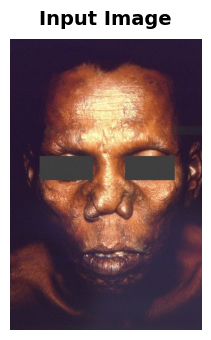


 Running inference with Weighted Average ensemble...
Inference completed successfully

PREDICTION RESULTS 
Ensemble Method: Weighted Average
Image Resolution: 320x320
Prediction: Tinea Capitis
Confidence: 75.1%

Class Probabilities:
----------------------------------------
1. Tinea Capitis      |  75.1% *
2. Tinea Corporis     |   9.2% 
3. Tinea Cruris       |   8.5% 
4. Tinea Unguium      |   5.2% 
5. Tinea Pedis        |   2.0% 
* = Predicted class
----------------------------------------


=== SECTION 6 completed: Real-time tinea classification demo finished ===



In [ ]:
# ==============================================================================
# SECTION 6: Real-Time Tinea Classification Demo
# ==============================================================================

print("=== SECTION 6: Real-Time Tinea Classification Demo ===")

# --- 1. Import necessary libraries ---
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from PIL import Image
import matplotlib.pyplot as plt
import json
import warnings
from sklearn.linear_model import LogisticRegression
from urllib.request import urlopen
from io import BytesIO
import albumentations as A
import cv2

# Suppress warnings for cleaner demo
warnings.filterwarnings("ignore")

# --- 2. Environment setup ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Environment: Google Colab detected.")
except Exception:
    IN_COLAB = False
    print("Environment: Not running in Colab.")

if IN_COLAB:
    DRIVE_MOUNT_POINT = "/content/drive"
    if not os.path.ismount(DRIVE_MOUNT_POINT):
        print("Mounting Google Drive at", DRIVE_MOUNT_POINT)
        drive.mount(DRIVE_MOUNT_POINT)
        print("Google Drive mounted.")
else:
    DRIVE_MOUNT_POINT = None

# Set up directory paths
BASE_OUTPUT_DIR = os.path.join(DRIVE_MOUNT_POINT, "MyDrive", "v23_full_aug") if IN_COLAB else os.path.abspath("v23_full_aug_local")
MODELS_DIR = os.path.join(BASE_OUTPUT_DIR, "models")
CLINICAL_METRICS_DIR = os.path.join(BASE_OUTPUT_DIR, "clinical_metrics")
VIZ_DIR = os.path.join(BASE_OUTPUT_DIR, "visualizations")

print("\nDirectory structure:")
print(f"  Models Directory: {MODELS_DIR}")
print(f"  Clinical Metrics Directory: {CLINICAL_METRICS_DIR}")

# --- Class Constants ---
CLASS_NAMES = [
    "Tinea Capitis",
    "Tinea Corporis",
    "Tinea Cruris",
    "Tinea Pedis",
    "Tinea Unguium"
]
NUM_CLASSES = len(CLASS_NAMES)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
resolution=[320,320]

# --- Helper functions ---
def load_best_ensemble_config():
    """Load the best ensemble configuration"""
    try:
        # Find latest ensemble config
        ensemble_files = [f for f in os.listdir(CLINICAL_METRICS_DIR)
                         if f.startswith('ensemble_config_') and f.endswith('.json')]
        if not ensemble_files:
            print("No ensemble configuration found")
            return None

        ensemble_files.sort(reverse=True)
        latest_ensemble = ensemble_files[0]
        ensemble_path = os.path.join(CLINICAL_METRICS_DIR, latest_ensemble)

        print(f"Loading latest ensemble config: {latest_ensemble}")
        with open(ensemble_path, 'r') as f:
            return json.load(f)

    except Exception as e:
        print(f"Error loading ensemble configuration: {e}")
        return None

def find_model_directory(model_name):
    """Find the directory that starts with the model name in the models directory"""
    try:
        # List all directories in the models directory
        all_items = os.listdir(MODELS_DIR)
        model_dirs = [d for d in all_items
                     if os.path.isdir(os.path.join(MODELS_DIR, d)) and d.startswith(model_name)]

        if not model_dirs:
            print(f"No directories found starting with '{model_name}' in {MODELS_DIR}")
            print(f"   Available directories: {', '.join([d for d in all_items if os.path.isdir(os.path.join(MODELS_DIR, d))])}")
            return None

        # Sort by timestamp (newest first)
        model_dirs.sort(reverse=True)
        latest_dir = model_dirs[0]
        dir_path = os.path.join(MODELS_DIR, latest_dir)
        print(f"Found {model_name} directory: {latest_dir}")
        return dir_path

    except Exception as e:
        print(f"Error finding {model_name} directory: {e}")
        return None

def find_model_file(model_dir, model_name, resolution_label):
    try:
        # List all .keras files in the model directory
        model_files = [f for f in os.listdir(model_dir) if f.endswith('.keras')]

        if not model_files:
            print(f"No .keras files found in {model_dir}")
            return None

        # Look for files with the pattern "final_{model_name}_{resolution_label}.keras"
        pattern = f"final_{model_name}_{resolution_label}.keras"
        matching_files = [f for f in model_files if f.startswith(pattern.split('.')[0])]

        if not matching_files:
            # Try broader pattern
            pattern = f"{model_name}_{resolution_label}.keras"
            matching_files = [f for f in model_files if f.startswith(pattern.split('.')[0])]

        if not matching_files:
            print(f"No matching model files found for {model_name} at {resolution_label} in {model_dir}")
            print(f"   Searched for files starting with: {pattern.split('.')[0]}")
            print(f"   Available files: {', '.join(model_files)}")
            return None

        # Get the most recent matching file
        matching_files.sort(reverse=True)
        return matching_files[0]

    except Exception as e:
        print(f"Error finding model file in {model_dir}: {e}")
        return None

def load_models_for_ensemble(ensemble_config):
    """Load all models required for the ensemble - DYNAMIC DIRECTORY HANDLING"""
    try:
        models_in_ensemble = ensemble_config['models_in_ensemble']
        resolution = ensemble_config['resolution']
        resolution_label = f"{resolution[0]}x{resolution[1]}"

        print(f"\nLoading models for ensemble at {resolution_label}...")
        loaded_models = {}
        model_directories = {}

        # First find all model directories
        for model_name in models_in_ensemble:
            model_dir = find_model_directory(model_name)
            if model_dir is None:
                continue
            model_directories[model_name] = model_dir

        # Now load models from their directories
        for model_name, model_dir in model_directories.items():
            model_file = find_model_file(model_dir, model_name, resolution_label)
            if model_file is None:
                continue

            model_path = os.path.join(model_dir, model_file)

            print(f"   Loading {model_name} from: {model_file}")
            model = load_model(model_path, compile=False)
            loaded_models[model_name] = model
            print(f"   {model_name} loaded successfully")

        if len(loaded_models) == 0:
            print("Failed to load any models for ensemble")
            return None

        return loaded_models

    except Exception as e:
        print(f"Error loading models: {e}")
        import traceback
        traceback.print_exc()
        return None

def load_stacking_meta_model(ensemble_config):
    """Load stacking meta-model parameters"""
    try:
        if 'stacking' not in ensemble_config:
            print("  No stacking parameters found in ensemble config")
            return None

        stacking_params = ensemble_config['stacking']
        meta_model_params = stacking_params.get('meta_model_params', {})

        if not meta_model_params:
            print("  No meta-model parameters found")
            return None

        # Reconstruct logistic regression meta-model
        meta_model = LogisticRegression(max_iter=1000, random_state=SEED)

        # Create dummy data to initialize model
        dummy_X = np.zeros((2, NUM_CLASSES * len(ensemble_config['models_in_ensemble'])))
        dummy_y = [0, 1]
        meta_model.fit(dummy_X, dummy_y)

        # Load real parameters
        meta_model.coef_ = np.array(meta_model_params['coefficients'])
        meta_model.intercept_ = np.array(meta_model_params['intercept'])
        meta_model.classes_ = np.array(meta_model_params['classes'])

        return meta_model

    except Exception as e:
        print(f"Error loading stacking meta-model: {e}")
        return None

def preprocess_images_for_inference(img, target_size):
    try:
        img = img.convert("RGB")
        x = np.array(img)
        transform = A.Compose([A.Resize(height=256, width=256),A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))])
        transformed = transform(image=x)
        processed_img = transformed['image']
        return np.expand_dims(processed_img, axis=0), processed_img
    except Exception as e:
        print(f"Preprocessing error: {e}")
        return None, None

def run_ensemble_prediction(models, ensemble_config, img_array):
    """Run ensemble prediction using the configured method"""
    try:
        best_ensemble = ensemble_config['best_ensemble']
        resolution = [256,256] #ensemble_config['resolution']

        # Get predictions from each model
        predictions = []

        for model_name, model in models.items():
            pred = model.predict(img_array, verbose=0)[0]
            predictions.append(pred)

        # Weighted Average Ensemble
        if best_ensemble == "Weighted Average":
            weights = ensemble_config['weighted_average']['weights']

            weighted_pred = np.zeros((NUM_CLASSES,))
            for i, (model_name, pred) in enumerate(zip(ensemble_config['models_in_ensemble'], predictions)):
                weight = weights.get(model_name, 1.0 / len(models))
                weighted_pred += weight * pred

            final_pred = weighted_pred
            confidence = np.max(final_pred)
            pred_class = np.argmax(final_pred)
            return CLASS_NAMES[pred_class], confidence * 100, final_pred, best_ensemble

        # Stacking Ensemble
        elif best_ensemble == "Stacking":
            # Load meta-model
            meta_model = load_stacking_meta_model(ensemble_config)
            if meta_model is None:
                print("  Falling back to Weighted Average (stacking meta-model not available)")
                return run_weighted_average_fallback(models, ensemble_config, img_array)

            # Prepare features for meta-model
            test_features = np.concatenate(predictions).reshape(1, -1)
            stacking_proba = meta_model.predict_proba(test_features)[0]

            confidence = np.max(stacking_proba)
            pred_class = np.argmax(stacking_proba)
            return CLASS_NAMES[pred_class], confidence * 100, stacking_proba, best_ensemble

        else:
            print(f"  Unknown ensemble method: {best_ensemble}. Using Weighted Average as fallback.")
            return run_weighted_average_fallback(models, ensemble_config, img_array)

    except Exception as e:
        print(f"Ensemble prediction error: {e}")
        import traceback
        traceback.print_exc()
        # Fallback to simple average
        avg_pred = np.mean(predictions, axis=0)
        confidence = np.max(avg_pred)
        pred_class = np.argmax(avg_pred)
        return CLASS_NAMES[pred_class], confidence * 100, avg_pred, "Simple Average"

def run_weighted_average_fallback(models, ensemble_config, img_array):
    """Fallback to weighted average if other methods fail"""
    try:
        weights = ensemble_config.get('weighted_average', {}).get('weights', {})
        if not weights:
            # Use uniform weights if no weights available
            weights = {name: 1.0/len(models) for name in models.keys()}

        predictions = []

        for model_name, model in models.items():
            pred = model.predict(img_array, verbose=0)[0]
            predictions.append(pred)

        weighted_pred = np.zeros((NUM_CLASSES,))
        for i, (model_name, pred) in enumerate(zip(ensemble_config['models_in_ensemble'], predictions)):
            weight = weights.get(model_name, 1.0 / len(models))
            weighted_pred += weight * pred

        final_pred = weighted_pred
        confidence = np.max(final_pred)
        pred_class = np.argmax(final_pred)
        return CLASS_NAMES[pred_class], confidence * 100, final_pred, "Weighted Average (Fallback)"

    except Exception as e:
        print(f"Weighted average fallback error: {e}")
        avg_pred = np.mean(predictions, axis=0)
        confidence = np.max(avg_pred)
        pred_class = np.argmax(avg_pred)
        return CLASS_NAMES[pred_class], confidence * 100, avg_pred, "Simple Average"

def display_image(img):
    """Display image in a pixel box for clear visualization"""
    plt.figure(figsize=(3.5, 3.5), dpi=100)  # 3.5 inches * 100 DPI = 350 pixels
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image', fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

def preprocess_image_for_inference(img, target_size):
    try:
        img = img.convert("RGB")
        x = np.array(img)
        #resize and normalize
        transform = A.Compose([
            A.Resize(height=320, width=320),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
        ])
        transformed = transform(image=x)
        processed_img = transformed['image']
        return np.expand_dims(processed_img, axis=0), processed_img

    except Exception as e:
        print(f"Preprocessing error: {e}")
        return None, None

def main_demo():
    """Main interactive demo function"""
    print("\n" + "="*60)
    print("REAL TIME TINEA CLASSIFICATION DEMO (v16)")
    print("="*60)

    # Step 1: Load ensemble configuration
    print("\nStep 1: Loading best ensemble configuration...")

    ensemble_config = load_best_ensemble_config()
    if ensemble_config is None:
        print("Cannot proceed without ensemble configuration")
        return

    # List all directories in the models directory
    print("\nDirectory structure in models directory:")
    for item in os.listdir(MODELS_DIR):
        item_path = os.path.join(MODELS_DIR, item)
        if os.path.isdir(item_path):
            print(f"   {item}/")
        else:
            print(f"   {item}")

    print(f"Loaded ensemble configuration. Resolution: {ensemble_config['resolution']}")
    print(f"   Best ensemble: {ensemble_config['best_ensemble']}")
    print(f"   Models in ensemble: {ensemble_config['models_in_ensemble']}")

    models = load_models_for_ensemble(ensemble_config)
    if models is None:
        print("Cannot proceed without loaded models")
        return

    resolution = ensemble_config['resolution']
    best_ensemble = ensemble_config['best_ensemble']

    print(f"\nSystem ready for inference at {resolution[0]}x{resolution[1]} resolution")
    print(f"   Using {best_ensemble} ensemble with {len(models)} models")

    print(f"\nChoose Input Method")
    print("  [1] Upload local image file")
    print("  [2] Enter public image URL")
    input_choice = input("\nEnter choice (1 or 2): ").strip()

    # Load image
    img_path = None
    if input_choice == "1":
        try:
            if IN_COLAB:
                from google.colab import files
                print("Upload an image...")
                uploaded = files.upload()
                img_path = list(uploaded.keys())[0]
                img = Image.open(img_path)
            else:
                path = input("Enter local image path: ").strip()
                img_path = path
                img = Image.open(path)
            print(f"Image loaded successfully: {img.size}")
        except Exception as e:
            print(f"Error loading image: {e}")
            return
    elif input_choice == "2":
        try:
            url = input("Enter image URL: ").strip()
            img_path = url
            print("Downloading image...")
            img = Image.open(BytesIO(urlopen(url).read()))
            print(f"Image downloaded successfully: {img.size}")
        except Exception as e:
            print(f"Error downloading image: {e}")
            return
    else:
        print("Invalid choice")
        return

    display_image(img)
    img_array, processed_img = preprocess_images_for_inference(img, resolution)
    if img_array is None:
        print("Preprocessing failed")
        return

    print(f"\n Running inference with {best_ensemble} ensemble...")
    try:
        pred_class, conf, probs, actual_ensemble = run_ensemble_prediction(
            models, ensemble_config, img_array
        )
        print(f"Inference completed successfully")
    except Exception as e:
        print(f"Inference failed: {e}")
        return

    if conf < 70:
        display_class = "Low-confidence / Unknown"
    else:
        display_class = pred_class

    # Step 7: Display results in console
    print("\n" + "="*60)
    print("PREDICTION RESULTS ")
    print("="*60)
    print(f"Ensemble Method: {actual_ensemble}")
    print(f"Image Resolution: {resolution[0]}x{resolution[1]}")
    print(f"Prediction: {display_class}")
    print(f"Confidence: {conf:.1f}%")

    if conf < 70:
        print("\nWarning: Low confidence prediction.")

    print("\nClass Probabilities:")
    print("-" * 40)

    # Sort probabilities by value (highest to lowest)
    sorted_indices = np.argsort(probs)[::-1]
    for i, idx in enumerate(sorted_indices):
        cls = CLASS_NAMES[idx]
        p = probs[idx] * 100
        star = ""
        if cls == pred_class:
            star = "*"
        print(f"{i+1}. {cls:<18} | {p:5.1f}% {star}")

    if conf >= 70:
        print("* = Predicted class")

    print("-" * 40)
    if 'per_model_accuracies' in ensemble_config:
        for model_name, accuracy in ensemble_config['per_model_accuracies'].items():
            print(f"  {model_name}: {accuracy:.4f}")

    print("\n" + "="*60)

if __name__ == "__main__":
    try:
        main_demo()
    except KeyboardInterrupt:
        print("\n\nExited.")
    except Exception as e:
        print(f"\nUnexpected error during demo: {e}")
        import traceback
        traceback.print_exc()

print("\n=== SECTION 6 completed: Real-time tinea classification demo finished ===\n")